# Business Description
A specialty coffee roasting business that sources their own green coffee and either sells raw coffee to home roasters or roasted coffee on-demand daily to customers. The name I've come up with is "Comfy Mug" inspired by a great coffee roaster I love, Happy Mug.

# Tables/Schemas
*   Customers
*   Farmers
*   Employees
*   Inventory
*   Orders
*   OrderItems (additional table between Orders and Inventory)

## Relationships
*   Customer -> Orders(1:M): A customer can place multiple order, but a single order can only have one customer.
*   Orders -> OrderItems(1:M): One order can have multiple items, but each item can only have 1 order.
*   Inventory -> OrderItems(1:M): One type of coffee can appear in multiple orders, but each item can only have one type of coffee.
*   Orders <-> Inventory(M:M): Indirectly related. One order can have multiple inventory items, and one inventory item can be in multiple orders.
*   Farmers -> Inventory(1:M): A farmer can supply multiple lots of coffees, but each lot of coffee can only be supplied by one farmer.
*   Employees: This is just standalone for now.

## Diagram
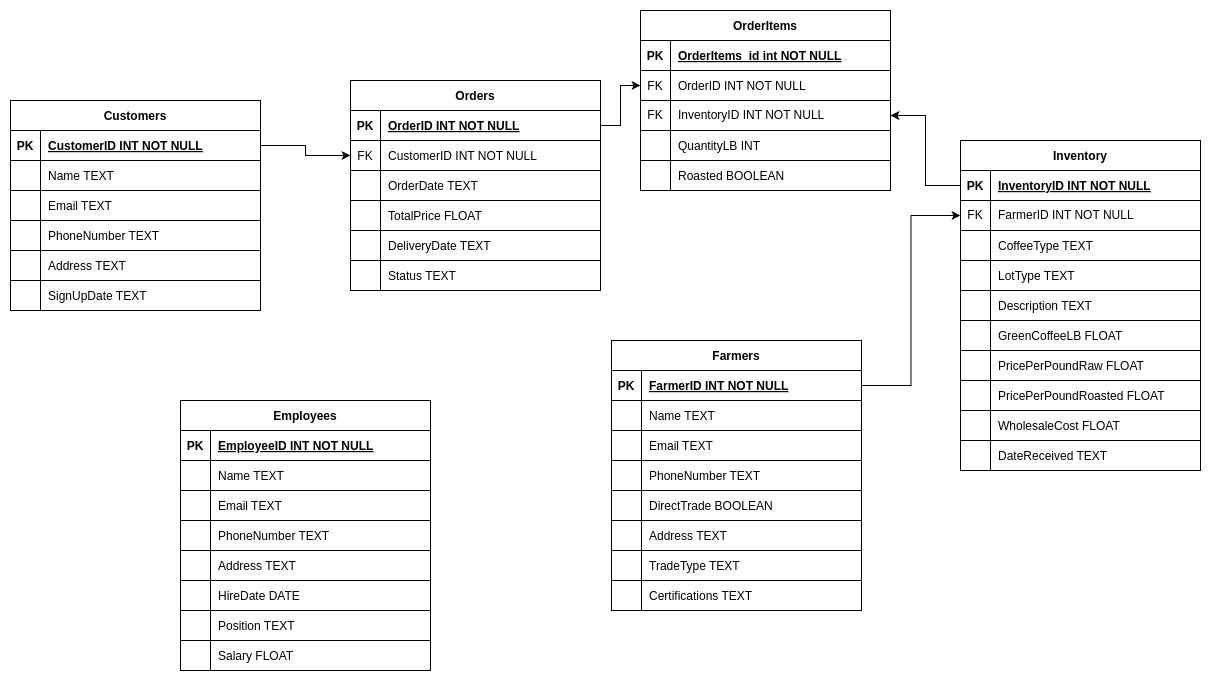

## Normal Form
In order to check what normal form it is in I have to check fo atomic values, partial dependencies, and non-key columns have to be dependent on the primary key. I believe my database is 3NF because all the non-key attributes depend on the primary key and no others.

# Implement the Database

In [164]:
# Imports
import sqlite3
import os

In [165]:
# Implement the Schema

# Check for comfymug.db file and delete it if it exists to restart the example
if os.path.exists('comfymug.db'):
    os.remove('comfymug.db')

# Connect to SQLite
conn = sqlite3.connect('comfymug.db')
cursor = conn.cursor()

# Create Tables
cursor.execute('''
    CREATE TABLE Customers (
        CustomerID INTEGER PRIMARY KEY,
        Name TEXT,
        Email TEXT,
        PhoneNumber TEXT,
        Address TEXT,
        SignUpDate TEXT
    )
''')

cursor.execute('''
    CREATE TABLE Farmers (
        FarmerID INTEGER PRIMARY KEY,
        Name TEXT,
        Email TEXT,
        PhoneNumber TEXT,
        DirectTrade BOOLEAN,
        Address TEXT,
        TradeType TEXT,
        Certifications TEXT
    )
''')

cursor.execute('''
    CREATE TABLE Employees (
        EmployeeID INTEGER PRIMARY KEY,
        Name TEXT,
        Email TEXT,
        PhoneNumber TEXT,
        Address TEXT,
        HireDate TEXT,
        Position TEXT,
        Salary FLOAT
    )
''')

cursor.execute('''
    CREATE TABLE Inventory (
        InventoryID INTEGER PRIMARY KEY,
        CoffeeType TEXT,
        LotType TEXT,
        Description TEXT,
        GreenCoffeeLB FLOAT,
        PricePerPoundRaw FLOAT,
        PricePerPoundRoasted FLOAT,
        WholesaleCost FLOAT,
        DateReceived TEXT,
        FarmerID INTEGER,
        FOREIGN KEY (FarmerID) REFERENCES Farmers(FarmerID)
    )
''')

cursor.execute('''
    CREATE TABLE Orders (
        OrderID INTEGER PRIMARY KEY,
        OrderDate TEXT,
        TotalPrice FLOAT,
        DeliveryDate TEXT,
        Status TEXT CHECK (Status IN ('Payment Processing','Pending', 'Shipped', 'En route', 'Delivered')),
        CustomerID INTEGER,
        FOREIGN KEY (CustomerID) REFERENCES Customers(CustomerID)
    )
''')

cursor.execute('''
    CREATE TABLE OrderItems (
        OrderItemsID INTEGER PRIMARY KEY,
        OrderID INTEGER,
        InventoryID INTEGER,
        QuantityLB INTEGER,
        Roasted BOOLEAN,
        FOREIGN KEY (OrderID) REFERENCES Orders(OrderID),
        FOREIGN KEY (InventoryID) REFERENCES Inventory(InventoryID)
    )
''')

conn.commit()

# Print out the Schema
tables = ["Customers", "Farmers", "Employees", "Inventory", "Orders", "OrderItems"]

for table in tables:
    print(f"Schema for {table}:")
    cursor.execute(f"PRAGMA table_info({table})")
    schema = cursor.fetchall()
    for column in schema:
        print(column)

    print("\n")

Schema for Customers:
(0, 'CustomerID', 'INTEGER', 0, None, 1)
(1, 'Name', 'TEXT', 0, None, 0)
(2, 'Email', 'TEXT', 0, None, 0)
(3, 'PhoneNumber', 'TEXT', 0, None, 0)
(4, 'Address', 'TEXT', 0, None, 0)
(5, 'SignUpDate', 'TEXT', 0, None, 0)


Schema for Farmers:
(0, 'FarmerID', 'INTEGER', 0, None, 1)
(1, 'Name', 'TEXT', 0, None, 0)
(2, 'Email', 'TEXT', 0, None, 0)
(3, 'PhoneNumber', 'TEXT', 0, None, 0)
(4, 'DirectTrade', 'BOOLEAN', 0, None, 0)
(5, 'Address', 'TEXT', 0, None, 0)
(6, 'TradeType', 'TEXT', 0, None, 0)
(7, 'Certifications', 'TEXT', 0, None, 0)


Schema for Employees:
(0, 'EmployeeID', 'INTEGER', 0, None, 1)
(1, 'Name', 'TEXT', 0, None, 0)
(2, 'Email', 'TEXT', 0, None, 0)
(3, 'PhoneNumber', 'TEXT', 0, None, 0)
(4, 'Address', 'TEXT', 0, None, 0)
(5, 'HireDate', 'TEXT', 0, None, 0)
(6, 'Position', 'TEXT', 0, None, 0)
(7, 'Salary', 'FLOAT', 0, None, 0)


Schema for Inventory:
(0, 'InventoryID', 'INTEGER', 0, None, 1)
(1, 'CoffeeType', 'TEXT', 0, None, 0)
(2, 'LotType', 'TEXT', 0

# Inserting Example Data

In [166]:
# Make up and insert 5 customers into the Customer table in the database

# Insert 5 customers
customers = [
    ('Alice Johnson', 'alice.johnson@example.com', '555-123-4567', '123 Main St', '2017-01-15'),
    ('Bob Williams', 'bob.williams@example.com', '555-987-6543', '456 Oak Ave', '2017-11-20'),
    ('Charlie Brown', 'charlie.brown@example.com', '555-111-2222', '789 Pine Ln', '2018-02-10'),
    ('David Lee', 'david.lee@example.com', '555-333-4444', '101 Maple Dr', '2023-12-05'),
    ('Eve Davis', 'eve.davis@example.com', '555-555-6666', '202 Birch Rd', '2024-03-01')
]

cursor.executemany('''
    INSERT INTO Customers (Name, Email, PhoneNumber, Address, SignUpDate)
    VALUES (?, ?, ?, ?, ?)
''', customers)

# Commit to DB
conn.commit()

In [167]:
# Make up and insert 5 farmers into the Farmers table in the database

# Insert 5 farmers
farmers = [
    ('Farmer Joe', 'farmerjoe@example.com', '555-111-1212', True, '123 Farm Rd', 'Direct', 'Organic'),
    ('Maria Sanchez', 'msanchez@example.com', '555-222-2323', False, '456 Ranch Ln', 'Intermediary Reseller', 'Bird Friendly'),
    ('David Kim', 'davidkim@example.com', '555-333-3434', True, '789 Acre Ave', 'Direct', 'Rainforest Alliance'),
    ('Linda Brown', 'lbrown@example.com', '555-444-4545', True, '101 Harvest Dr', 'Cooperative Union', 'Organic, Fair Trade'),
    ('Carlos Rodriguez', 'crodriguez@example.com', '555-555-5656', False, '202 Green Valley', 'Estate', 'None')
]

cursor.executemany('''
    INSERT INTO Farmers (Name, Email, PhoneNumber, DirectTrade, Address, TradeType, Certifications)
    VALUES (?, ?, ?, ?, ?, ?, ?)
''', farmers)

# Commit to DB
conn.commit()

In [168]:
# prompt: Make up and insert 5 coffees into the Inventory table in the database

# Insert 5 coffees
coffees = [
    ('Colombian Supremo', 'Single Origin Estate', 'Chocolate notes at Medium roast, Cherry notes at Light roast', 20.0, 6.50, 14.0, 40.0, '2024-04-20', 1),
    ('Ethiopian Durato Bombe', 'Single Origin Microlot', 'Citrusy, floral, tea like body at light roast', 50.0, 8.00, 16.0, 100.0, '2024-04-22', 2),
    ('Brazil Alta Mogiana', 'Blended Origin', 'Bold and earthy flavor at Medium and Dark roasts', 75.0, 5.75, 12.0, 150.0, '2024-04-25', 3),
    ('Kenyan AA', 'Single Origin High Grown', 'Bright acidity and black currant notes', 60.0, 7.25, 16.0, 120.0, '2024-04-28', 4),
    ('Guatemalan Huehuetenango', 'Single Origin Estate', 'Well-balanced with nutty chocolatety flavor', 80.0, 6.90, 14.0, 160.0, '2024-05-02', 5)
]

cursor.executemany('''
    INSERT INTO Inventory (CoffeeType, LotType, Description, GreenCoffeeLB, PricePerPoundRaw, PricePerPoundRoasted, WholesaleCost, DateReceived, FarmerID)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
''', coffees)

# Commit to DB
conn.commit()


In [169]:
# Make up and insert 5 workers into the Employee table in the database

# Insert 5 employees
employees = [
    ('John Smith', 'john.smith@example.com', '555-1212', '123 Main St', '2023-01-15', 'Roaster', 50000),
    ('Jane Doe', 'jane.doe@example.com', '555-1313', '456 Oak Ave', '2020-02-20', 'Warehouse', 30000),
    ('Kevin Lin', 'link@terpmail.umd.edu', '123-456-7890', '789 Pine Ln', '2016-03-10', 'Janitor', 12000),
    ('Sarah Lee', 'sarah.lee@example.com', '555-1515', '101 Maple Dr', '2023-04-05', 'Warehouse', 25000),
    ('David Wilson', 'david.wilson@example.com', '555-1616', '202 Birch Rd', '2023-05-01', 'Delivery Driver', 35000)
]

cursor.executemany('''
    INSERT INTO Employees (Name, Email, PhoneNumber, Address, HireDate, Position, Salary)
    VALUES (?, ?, ?, ?, ?, ?, ?)
''', employees)

# Commit to DB
conn.commit()

In [170]:
# This is still part of inserting 5 rows into the tables, but this requires multiple queries in order to calculate the Total Price, and updates in order to remove stock from the Inventory.

# Fetch Customer IDs
cursor.execute("SELECT CustomerID FROM Customers")
customer_ids = [row[0] for row in cursor.fetchall()]

# Fetch Inventory data but put Roasted and Raw prices in separate dicts to simplify logic
cursor.execute("SELECT InventoryID, PricePerPoundRaw FROM Inventory")
rawprice = {row[0]: row[1] for row in cursor.fetchall()}
cursor.execute("SELECT InventoryID, PricePerPoundRoasted FROM Inventory")
roastedprice = {row[0]: row[1] for row in cursor.fetchall()}

# Sample order data
orders_data = [
    (customer_ids[0], '2025-02-10', [(1, 2, True), (2, 1, False)]),  # Customer 1, 2 lbs of Colombian Roasted, 1 lb of Ethiopian Raw
    (customer_ids[1], '2025-02-10', [(3, 3, True)]),        # Customer 2, 3 lbs of Brazil Roasted
    (customer_ids[2], '2025-02-10', [(4, 1, True), (5, 2, True)]), # Customer 3, 1 lb of Kenyan, 2 lbs of Guatemalan
    (customer_ids[3], '2025-02-10', [(1, 1, False)]),        # Customer 4, 1 lb of Colombian Raw
    (customer_ids[4], '2025-02-10', [(2, 2, False), (3, 1, False)])   # Customer 5, 2 lbs of Ethiopian, 1 lb of Brazil
]

# Figure out the total price and create the orders in the Orders table
for customer_id, order_date, items in orders_data:

    # Get the total price of the order
    total_price = 0
    for inventory_id, quantity, roasted in items:

        # Different price if the coffee is roasted or not
        if roasted:
            total_price += roastedprice[inventory_id] * quantity
        else:
            total_price += rawprice[inventory_id] * quantity

        # Also remove the ordered amount from the Inventory table
        cursor.execute('''
            UPDATE Inventory
            SET GreenCoffeeLB = GreenCoffeeLB - ?
            WHERE InventoryID = ?
        ''', (quantity, inventory_id))

    # Insert into Orders table
    cursor.execute('''
        INSERT INTO Orders (CustomerID, OrderDate, TotalPrice, DeliveryDate, Status)
        VALUES (?, ?, ?, ?, ?)
    ''', (customer_id, order_date, total_price, '2025-02-25', 'Pending'))

    # Get the id of the row just created
    order_id = cursor.lastrowid

    # Insert each item in the order into OrderItems table using that OrderID
    for inventory_id, quantity, roasted in items:
        cursor.execute('''
            INSERT INTO OrderItems (OrderID, InventoryID, QuantityLB, Roasted)
            VALUES (?, ?, ?, ?)
        ''', (order_id, inventory_id, quantity, roasted))

conn.commit()

# Querying Database

In [171]:
# Query the database to answer 4 questions (Making sure to use JOIN, WHERE, aggregate function, and GROUP BY)

# 1. What if a coffee is running low? Throw a warning if the QuantityLB in Inventory is below 20 pounds (arbitrary for now).
cursor.execute('''
    SELECT InventoryID, CoffeeType, GreenCoffeeLB
    FROM Inventory
    WHERE GreenCoffeeLB < 20
''')
low_stock = cursor.fetchall()
print("Low Stock:")
for row in low_stock:
    print(f"InventoryID: {row[0]}, CoffeeType: {row[1]}, QuantityLB: {row[2]}")

print("\n\n")

# 1. What if a customer forgot what they ordered and want to check? Query OrderItems using OrderID and InventoryID to query Inventory to return the name of the coffee and how many pounds were ordered.
order_id = 3
cursor.execute('''
    SELECT OrderItems.OrderID, OrderItems.InventoryID, OrderItems.QuantityLB, Inventory.CoffeeType
    FROM OrderItems
    JOIN Inventory ON OrderItems.InventoryID = Inventory.InventoryID
    WHERE OrderItems.OrderID = ?
''', (order_id,))
order_items = cursor.fetchall()
print("Items for order 3:")
for row in order_items:
    print(f"{row[2]} pound(s) of {row[3]}")

print("\n\n")

# 3. What is the average number of different coffees per order? Query OrderID against OrderItems using GROUPBY and COUNT to return a list of items per order, then calculate the average.
cursor.execute('''
    SELECT OrderID, COUNT(*) AS NumItems
    FROM OrderItems
    GROUP BY OrderID
''')
items_per_order = cursor.fetchall()
total_orders = len(items_per_order)
total_items = sum(row[1] for row in items_per_order)
average_items = total_items / total_orders
print(f"Average number of different coffees per order: {average_items:.2f}")

print("\n\n")

# 4. What if we wanted to query all customers who have been signed up for 2 years or more to send them a complementary gift card over the email? Query CustomerID and SignUpDate first, then after processing the SignUpDate string go back and query the emails of customers who qualify.
cursor.execute('''
    SELECT CustomerID, SignUpDate
    FROM Customers
''')
customers = cursor.fetchall()

# Process the SignUpDate string
result = []
for customer_id, signup_date in customers:
    year, month, day = map(int, signup_date.split('-'))
    if 2025 - year >= 2:
        result.append(customer_id)

# Query again
print("Customers who qualify for a gift card:")
for customer_id in result:
    cursor.execute('''
        SELECT Name, Email
        FROM Customers
        WHERE CustomerID = ?
    ''', (customer_id,))
    name, email = cursor.fetchone()
    print(f"Customer: {name}, Email: {email}")


conn.close()

Low Stock:
InventoryID: 1, CoffeeType: Colombian Supremo, QuantityLB: 17.0



Items for order 3:
1 pound(s) of Kenyan AA
2 pound(s) of Guatemalan Huehuetenango



Average number of different coffees per order: 1.60



Customers who qualify for a gift card:
Customer: Alice Johnson, Email: alice.johnson@example.com
Customer: Bob Williams, Email: bob.williams@example.com
Customer: Charlie Brown, Email: charlie.brown@example.com
Customer: David Lee, Email: david.lee@example.com


## Discuss More Complex Data Science Algorithms
The most likely thing to do in a shop trying to sell items is a product recommendation system. Something like Content-Based Filtering discussed in Data 602 where we use a customer's past purchases or viewing history to try and recommend products. Things that would be taken into consideration would be things like flavors, terroirs, certifications, roast level, and so on.

# Scale
*   Now imagine your company, and therefore data, has grown too large for
a lightweight database like sqlite. What might be your next step up in
scale (while still keeping the data in a relational database)?
   *   Something like MongoDB, or PostgreSQL could be next steps when the data outgrows sqlite. Researching online, I see that SQLite3 has limited capability in parallelism, concurrency, replication, or sharding hence options to scale horizontally are limited. Hence, any SQL database that supports replication and sharding seems like a good next step which will allow the current database to be easily ported over.
*   Imagine further that the data can no longer fit on a single
machine/server running your database. How might you scale it (again,
still keeping it as a relational database)?
   *   What options do you have to scale your data?
      *   Replication and sharding both seems to work in this scenario. It might not be fair to alter the premise slightly, but if the business is success enough that the data can no longer fit on one server then I can probably open the business in other locations/regions. I can then shard the database to handle each region, and if specific regions are too read/write intensive then replication with eventualy consistency can be further implemented for each shard.
   *   What kinds of things might you need to weigh for your particular business?
      *   In this case, I believe availability can be prioritized and eventual consistency be used with a caveat. The main problem in this scenario is the problem of selling someone coffee after the stock as run out if the servers are only eventually consistent. This can be remedied by keeping track of the rate of orders of the different coffees and to disallow eventual consistency when down to the last of the stock by only letting one server handle the writes. While this is technically a single point of failure, I believe if you can reduce the time spent in this psuedo read-replica mode, you can reduce risk.